<a href="https://colab.research.google.com/github/sharvani1357/hierarch_cluster/blob/main/dbscan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler

In [ ]:
df=pd.read_csv("Mall_Customers.csv")

In [ ]:
df.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
import matplotlib.pyplot as plt     # For visualization
from sklearn.cluster import DBSCAN  # DBSCAN clustering algorithm
from sklearn.preprocessing import StandardScaler

In [ ]:
x = df[['Annual Income (k$)', 'Spending Score (1-100)']]
x

,Annual Income (k$),Spending Score (1-100)
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40
...,...,...
195,120,79
196,126,28
197,126,74
198,137,18


In [ ]:
scaler=StandardScaler()
x_scaled = scaler.fit_transform(x)
x_scaled

array([[-1.73899919, -0.43480148],
       [-1.73899919,  1.19570407],
       [-1.70082976, -1.71591298],
       [-1.70082976,  1.04041783],
       [-1.66266033, -0.39597992],
       [-1.66266033,  1.00159627],
       [-1.62449091, -1.71591298],
       [-1.62449091,  1.70038436],
       [-1.58632148, -1.83237767],
       [-1.58632148,  0.84631002],
       [-1.58632148, -1.4053405 ],
       [-1.58632148,  1.89449216],
       [-1.54815205, -1.36651894],
       [-1.54815205,  1.04041783],
       [-1.54815205, -1.44416206],
       [-1.54815205,  1.11806095],
       [-1.50998262, -0.59008772],
       [-1.50998262,  0.61338066],
       [-1.43364376, -0.82301709],
       [-1.43364376,  1.8556706 ],
       [-1.39547433, -0.59008772],
       [-1.39547433,  0.88513158],
       [-1.3573049 , -1.75473454],
       [-1.3573049 ,  0.88513158],
       [-1.24279661, -1.4053405 ],
       [-1.24279661,  1.23452563],
       [-1.24279661, -0.7065524 ],
       [-1.24279661,  0.41927286],
       [-1.20462718,

In [ ]:
dbscan=DBSCAN(eps=0.3,min_samples=5)
clusters=dbscan.fit_predict(x_scaled)

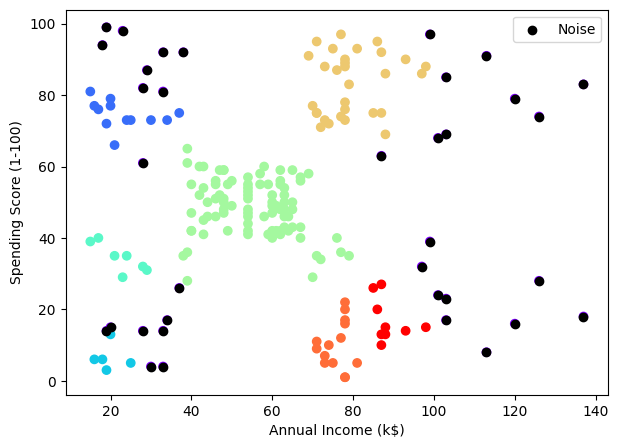

In [ ]:
plt.figure(figsize=(7,5))

# All points colored by cluster
plt.scatter(
    x['Annual Income (k$)'],
    x['Spending Score (1-100)'],
    c=clusters,
    cmap='rainbow'
)

# Noise points (cluster = -1)
plt.scatter(
    x.iloc[clusters == -1]['Annual Income (k$)'],
    x.iloc[clusters == -1]['Spending Score (1-100)'],
    color='black',
    label='Noise'
)

plt.xlabel('Annual Income (k$)')
plt.ylabel('Spending Score (1-100)')
plt.legend()
plt.show()

In [ ]:
eps_value=[0.2,0.3,0.5]
for eps in eps_value:
  print(f"\n Evaluating DBSCAN using eps={eps}")
  dbscan=DBSCAN(eps=eps,min_samples=5)
  labels=dbscan.fit_predict(x_scaled)

  unique_labels=set(labels)
  n_clusters=len(unique_labels)-(1 if -1 in unique_labels else 0)

  n_noise=list(labels).count(-1)
  noise_ratio=n_noise/len(labels)
  print(f"Number of clusters: {n_clusters}")
  print(f"Number of noise points:",round(noise_ratio,2))




 Evaluating DBSCAN using eps=0.2
Number of clusters: 7
Number of noise points: 0.39

 Evaluating DBSCAN using eps=0.3
Number of clusters: 7
Number of noise points: 0.17

 Evaluating DBSCAN using eps=0.5
Number of clusters: 2
Number of noise points: 0.04


In [ ]:
if n_